# Step 5: Viscosity and the grid Reynolds number

Does the momentum side of the model change the numerical mixing of the tracer? Ilicak et al. (2012) found that spurious mixing grows with the grid Reynolds number Re = U dx / nu, and that it is "high and steady (capped)" above about 100. I kept the tracer scheme fixed (WENO, 5th order) on the baseline grid (dx = 500 m, dz = 1 m) and varied the lateral viscosity from 0.01 to 200 m^2/s, first with centred (2nd order) momentum advection, which has no damping of its own, and then with WENO momentum advection, which does (`simulations/run_step5.jl`).

I load the libraries and shared functions and set the parameters. The grid Reynolds number follows Ilicak et al. (2012, Eq. 7): U is the theoretical front speed 0.5 sqrt(g' H) = 0.495 m/s.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at, density)

VISCOSITIES = [0.01, 0.1, 1.0, 10.0, 100.0, 200.0]   # lateral viscosity nu_h (m^2/s)
DX = 500.0                                             # grid spacing (m)
U_FRONT = 0.5 * np.sqrt(DELTA_B * DEPTH)               # velocity scale for the grid Reynolds number (m/s)
SETS = {"centred momentum": "cmom", "WENO momentum": "wmom"}
COLORS = {"centred momentum": "tab:red", "WENO momentum": "tab:blue"}
FIT_START, FIT_END = 3 * 3600, 15 * 3600
FIG_DIR = "../figures"
DATA_DIR = "../data"

def run_name(short, nu):
    if short == "wmom" and nu == 0.01:
        return "step2_baseline_weno"                   # the baseline is the WENO-momentum run with nu = 0.01
    return f"step5_{short}_nu" + str(nu).replace(".", "p")

For every run I compute the mixing measures and two more things. First, the grid Reynolds number with a measured velocity as well (the largest |u| at 17 h), to see how much the choice of velocity scale matters. Second, a measure of grid-scale noise in the velocity: at every point, how far u differs from the average of its two horizontal neighbours, (u[i-1] - 2 u[i] + u[i+1]) / 4, as a root-mean-square over the domain at 17 h. A smooth field gives a small value; a zigzag from cell to cell (the noise that centred schemes allow) gives a large one.

In [2]:
def grid_noise(u):
    # root-mean-square of the cell-to-cell zigzag in u along x, (u[i-1] - 2 u[i] + u[i+1]) / 4
    second_difference = (u[:, :-2] - 2 * u[:, 1:-1] + u[:, 2:]) / 4
    return np.sqrt(np.mean(second_difference ** 2))

rows = []
for label, short in SETS.items():
    for nu in VISCOSITIES:
        ds, log, info = load_run(run_name(short, nu))
        times = ds.time.values
        rpe = rpe_series(ds)
        variance = buoyancy_variance(ds)
        right, left = front_positions(ds)
        u_end = ds["u"].sel(time=17 * 3600, method="nearest").values
        rho_end = density(ds["b"].sel(time=17 * 3600, method="nearest").values)
        u_max = log["u_max_abs"].iloc[-1]
        rows.append({"momentum": label, "nu_h": nu, "grid_reynolds": U_FRONT * DX / nu,
                     "grid_reynolds_measured_u": u_max * DX / nu,
                     "rpe_change_17h": (rpe[-1] - rpe[0]) / rpe[0],
                     "drpe_dt_17h_W_m2": rpe_rate_at(times, rpe, 17 * 3600, 3600) / LENGTH,
                     "variance_change_17h": (variance[-1] - variance[0]) / variance[0],
                     "mixed_fraction": np.mean((rho_end > density(DELTA_B) + 0.05) & (rho_end < density(0.0) - 0.05)),
                     "overshoot": max(log["b_max"].max() - DELTA_B, 0) / DELTA_B,
                     "rpe_smallest_step": np.min(np.diff(rpe)) / rpe[0],
                     "grid_noise_u_m_s": grid_noise(u_end), "u_max_17h": u_max,
                     "front_speed_m_s": front_speed(times, right, FIT_START, FIT_END),
                     "status": info["status"], "iterations": int(info["iterations"]), "wall_time_s": float(info["wall_time_s"])})
table = pd.DataFrame(rows)
table.to_csv(os.path.join(DATA_DIR, "step5_viscosity.csv"), index=False)
pd.set_option("display.width", 220)
print(table[["momentum", "nu_h", "grid_reynolds", "grid_reynolds_measured_u", "rpe_change_17h", "drpe_dt_17h_W_m2",
             "variance_change_17h", "mixed_fraction", "grid_noise_u_m_s", "front_speed_m_s", "status"]].to_string(index=False))
print("all completed:", all(table["status"] == "completed"), "| RPE never decreased:", all(table["rpe_smallest_step"] > 0),
      "| largest overshoot:", f"{table['overshoot'].max():.1e}")

        momentum   nu_h  grid_reynolds  grid_reynolds_measured_u  rpe_change_17h  drpe_dt_17h_W_m2  variance_change_17h  mixed_fraction  grid_noise_u_m_s  front_speed_m_s    status
centred momentum   0.01   24761.361029              43901.895000        0.000070          0.004068            -0.266886        0.482031          0.014583         0.451967 completed
centred momentum   0.10    2476.136103               4409.997500        0.000070          0.004056            -0.266493        0.482031          0.014452         0.451967 completed
centred momentum   1.00     247.613610                435.544450        0.000068          0.003938            -0.263007        0.477344          0.013712         0.452970 completed
centred momentum  10.00      24.761361                 42.045560        0.000059          0.003317            -0.244104        0.442188          0.012240         0.458369 completed
centred momentum 100.00       2.476136                  3.807788        0.000021          0.001

The main figure, in the style of Ilicak et al. (2012, Fig. 6): the rate of RPE increase at 17 h against the grid Reynolds number, for both momentum schemes, and the grid-scale noise in the velocity.

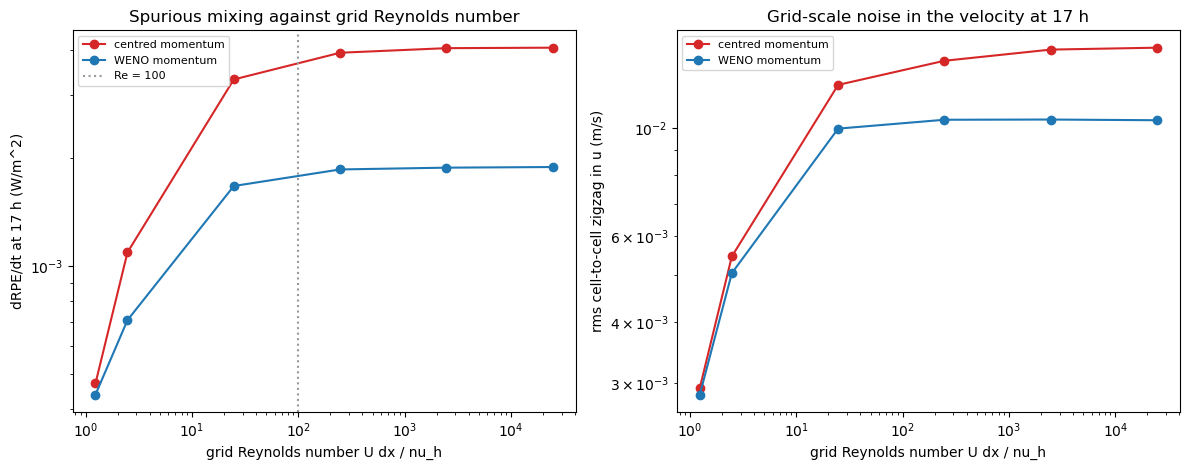

centred momentum: dRPE/dt for Re > 100 between 3.938e-03 and 4.068e-03 W/m^2 (spread 3%); at Re = 1.24: 4.710e-04, 8.6 times smaller than the largest
WENO momentum: dRPE/dt for Re > 100 between 1.861e-03 and 1.890e-03 W/m^2 (spread 2%); at Re = 1.24: 4.381e-04, 4.3 times smaller than the largest
ratio centred / WENO momentum, dRPE/dt: {0.01: np.float64(2.15), 0.1: np.float64(2.15), 1.0: np.float64(2.12), 10.0: np.float64(1.98), 100.0: np.float64(1.55), 200.0: np.float64(1.08)}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for label in SETS:
    sub = table[table["momentum"] == label]
    axes[0].loglog(sub["grid_reynolds"], sub["drpe_dt_17h_W_m2"], "o-", color=COLORS[label], label=label)
    axes[1].loglog(sub["grid_reynolds"], sub["grid_noise_u_m_s"], "o-", color=COLORS[label], label=label)
axes[0].axvline(100, color="0.6", ls=":", label="Re = 100")
axes[0].set_xlabel("grid Reynolds number U dx / nu_h")
axes[0].set_ylabel("dRPE/dt at 17 h (W/m^2)")
axes[0].set_title("Spurious mixing against grid Reynolds number")
axes[1].set_xlabel("grid Reynolds number U dx / nu_h")
axes[1].set_ylabel("rms cell-to-cell zigzag in u (m/s)")
axes[1].set_title("Grid-scale noise in the velocity at 17 h")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_mixing_vs_grid_reynolds.png"), dpi=150)
plt.show()

for label in SETS:
    sub = table[table["momentum"] == label].sort_values("grid_reynolds")
    high = sub[sub["grid_reynolds"] > 100]["drpe_dt_17h_W_m2"]
    print(f"{label}: dRPE/dt for Re > 100 between {high.min():.3e} and {high.max():.3e} W/m^2 "
          f"(spread {100 * (high.max() / high.min() - 1):.0f}%); at Re = {sub['grid_reynolds'].iloc[0]:.2f}: "
          f"{sub['drpe_dt_17h_W_m2'].iloc[0]:.3e}, {high.max() / sub['drpe_dt_17h_W_m2'].iloc[0]:.1f} times smaller than the largest")
cm = table[table["momentum"] == "centred momentum"].set_index("nu_h")
wm = table[table["momentum"] == "WENO momentum"].set_index("nu_h")
print("ratio centred / WENO momentum, dRPE/dt:", {nu: round(cm.loc[nu, "drpe_dt_17h_W_m2"] / wm.loc[nu, "drpe_dt_17h_W_m2"], 2) for nu in VISCOSITIES})

Buoyancy at 17 h with centred momentum advection for four viscosities. Ilicak et al. noted that high viscosity reduces the mixing but also changes the flow itself (the interface tilts and the shear is smoothed).

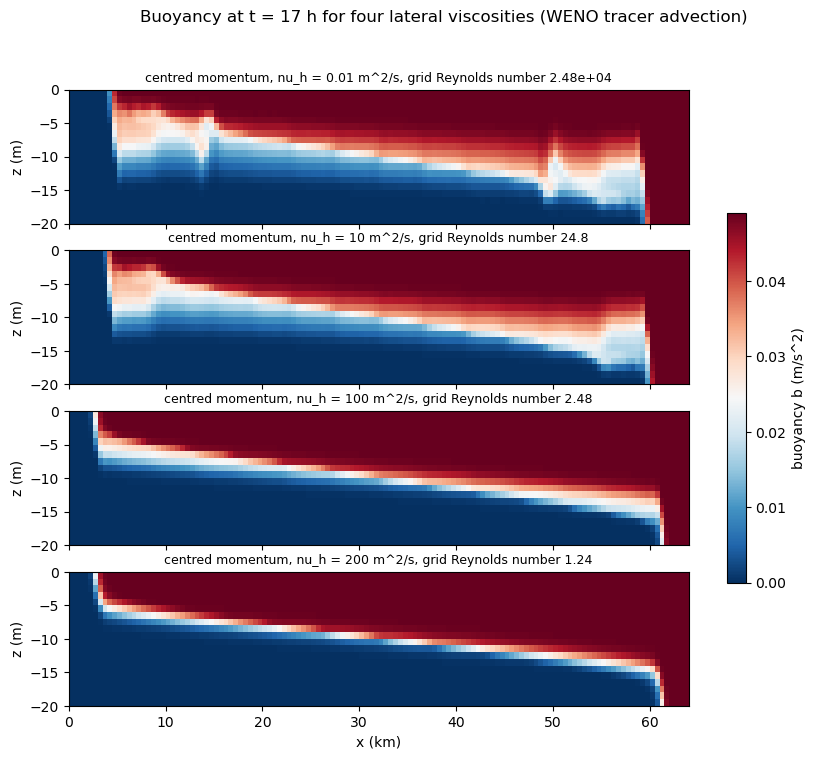

In [4]:
show = [0.01, 10.0, 100.0, 200.0]
fig, axes = plt.subplots(len(show), 1, figsize=(10, 8), sharex=True)
for ax, nu in zip(axes, show):
    ds, log, info = load_run(run_name("cmom", nu))
    snapshot = ds["b"].sel(time=17 * 3600, method="nearest")
    mesh = ax.pcolormesh(ds.x_caa / 1e3, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
    ax.set_ylabel("z (m)")
    ax.set_title(f"centred momentum, nu_h = {nu:g} m^2/s, grid Reynolds number {U_FRONT * DX / nu:.3g}", fontsize=9)
axes[-1].set_xlabel("x (km)")
fig.colorbar(mesh, ax=axes, label="buoyancy b (m/s^2)", shrink=0.6)
fig.suptitle("Buoyancy at t = 17 h for four lateral viscosities (WENO tracer advection)")
fig.savefig(os.path.join(FIG_DIR, "05_viscosity_snapshots.png"), dpi=150, bbox_inches="tight")
plt.show()

Front speed against grid Reynolds number: more mixing should mean a weaker density contrast and a slower current.

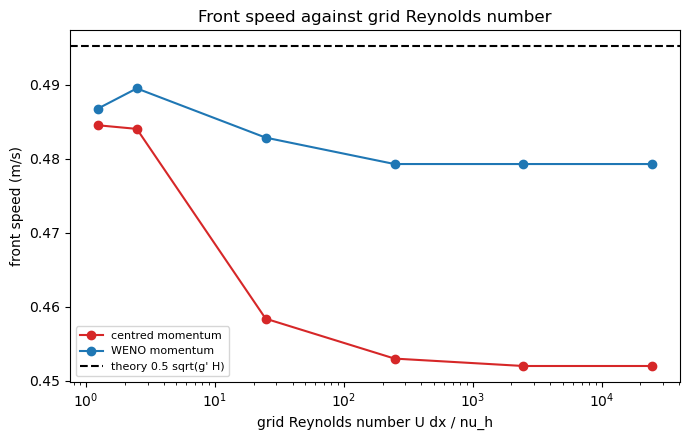

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label in SETS:
    sub = table[table["momentum"] == label]
    ax.semilogx(sub["grid_reynolds"], sub["front_speed_m_s"], "o-", color=COLORS[label], label=label)
ax.axhline(U_FRONT, color="k", ls="--", label="theory 0.5 sqrt(g' H)")
ax.set_xlabel("grid Reynolds number U dx / nu_h")
ax.set_ylabel("front speed (m/s)")
ax.set_title("Front speed against grid Reynolds number")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_front_speed_vs_grid_reynolds.png"), dpi=150)
plt.show()